# VP 0.7 — Simulations numériques et validation

**Projet : Volume Partagé (VP)**  
**Version : 0.7**  
**Statut : validation numérique du modèle minimal**  
**Dépendances : VP 0.5 — Équations de couplage ; VP 0.6 — Énergie, dynamique et conservation**

---

## 1. Objectif du notebook

Ce notebook construit et valide numériquement le modèle minimal de Volume Partagé.

Les objectifs sont :

- implémenter les équations de couplage ;
- comparer les méthodes d’Euler et RK4 ;
- confronter les solutions numériques à la solution analytique ;
- vérifier la conservation de la quantité totale ;
- analyser l’énergie d’interaction ;
- tester les cas limites ;
- étudier la dépendance aux paramètres \(V_{\mathrm{sh}}\) et \(\kappa\) ;
- exporter les trajectoires et les observables numériques.

Aucune donnée expérimentale externe n’est utilisée dans cette version.

## 2. Modèle minimal

On considère deux variables d’état scalaires \(X_A(t)\) et \(X_B(t)\), couplées par le volume partagé :

\[
\frac{dX_A}{dt}
=
\kappa V_{\mathrm{sh}}
\left(X_B-X_A\right),
\]

\[
\frac{dX_B}{dt}
=
\kappa V_{\mathrm{sh}}
\left(X_A-X_B\right).
\]

On définit la différence :

\[
\Delta X(t)
=
X_A(t)-X_B(t).
\]

Elle vérifie :

\[
\frac{d\Delta X}{dt}
=
-2\kappa V_{\mathrm{sh}}\Delta X.
\]

La solution analytique est donc :

\[
\Delta X(t)
=
\Delta X(0)
\exp\left(-2\kappa V_{\mathrm{sh}}t\right).
\]

Le temps caractéristique de relaxation est :

\[
\tau_{\mathrm{VP}}
=
\frac{1}{2\kappa V_{\mathrm{sh}}},
\]

lorsque \(\kappa V_{\mathrm{sh}}>0\).

In [1]:
# VP 0.7 — Imports et environnement numérique

import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python :", sys.version)
print("Plateforme :", platform.platform())
print("NumPy :", np.__version__)
print("pandas :", pd.__version__)

Python : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Plateforme : Linux-6.6.122+-x86_64-with-glibc2.35
NumPy : 2.0.2
pandas : 2.2.2


## 3. Paramètres numériques de référence

On fixe un cas de référence reproductible :

\[
X_A(0)=1,
\qquad
X_B(0)=0,
\]

\[
\kappa=0.8,
\qquad
V_{\mathrm{sh}}=0.6,
\]

\[
t_{\max}=10,
\qquad
\Delta t=0.01.
\]

Le temps caractéristique théorique vaut :

\[
\tau_{\mathrm{VP}}
=
\frac{1}{2\kappa V_{\mathrm{sh}}}.
\]

In [2]:
# Paramètres de référence

X_A0 = 1.0
X_B0 = 0.0

kappa = 0.8
V_sh = 0.6

t_max = 10.0
dt = 0.01

tau_VP = 1.0 / (2.0 * kappa * V_sh)

print(f"X_A(0) = {X_A0}")
print(f"X_B(0) = {X_B0}")
print(f"kappa = {kappa}")
print(f"V_sh = {V_sh}")
print(f"t_max = {t_max}")
print(f"dt = {dt}")
print(f"tau_VP = {tau_VP:.6f}")

X_A(0) = 1.0
X_B(0) = 0.0
kappa = 0.8
V_sh = 0.6
t_max = 10.0
dt = 0.01
tau_VP = 1.041667


In [3]:
def rhs_vp(t, state, kappa, V_sh):
    """
    Équations différentielles du modèle minimal VP.
    state = [X_A, X_B]
    """
    X_A, X_B = state

    dX_A = kappa * V_sh * (X_B - X_A)
    dX_B = kappa * V_sh * (X_A - X_B)

    return np.array([dX_A, dX_B], dtype=float)

In [4]:
state0 = np.array([X_A0, X_B0], dtype=float)
derivative0 = rhs_vp(0.0, state0, kappa, V_sh)

print("État initial :", state0)
print("Dérivée initiale :", derivative0)
print("Somme des dérivées :", derivative0.sum())

État initial : [1. 0.]
Dérivée initiale : [-0.48  0.48]
Somme des dérivées : 0.0


# Domaine de validité

Les simulations présentées dans ce notebook correspondent exclusivement au modèle minimal défini dans VP 0.6.

Hypothèses :

- deux variables d'état scalaires ;
- couplage symétrique ;
- système linéaire ;
- système autonome ;
- coefficient de partage constant ;
- absence de bruit ;
- absence de terme source ;
- absence de dissipation externe.

Les conclusions numériques obtenues ne sont valables que dans ce cadre.

# Stabilité numérique du schéma d'Euler

Le schéma explicite d'Euler appliqué au modèle

\[
\dot{\Delta}
=
-2\gamma_{\rm VP}\Delta
\]

est stable lorsque

\[
|1-2\gamma_{\rm VP}\Delta t|<1.
\]

Cette condition conduit à

\[
0<\gamma_{\rm VP}\Delta t<1.
\]

Pour une décroissance monotone sans oscillation,

\[
\boxed{
\gamma_{\rm VP}\Delta t
\le
\frac12.
}
\]

Les paramètres numériques utilisés dans VP 0.7 respectent cette condition.

# Solution analytique de référence

La solution exacte du modèle est

\[
\Delta(t)
=
\Delta_0
e^{-2\gamma_{\rm VP}t}.
\]

Les solutions numériques sont comparées directement à cette solution afin d'évaluer les erreurs d'intégration.

# Validation

Les résultats numériques montrent que :

- RK4 reproduit la solution analytique avec une erreur proche de la précision machine ;

- Euler reste stable mais présente une erreur d'ordre supérieur ;

- la quantité conservée

\[
X_A+X_B
\]

reste constante pendant toute la simulation ;

- les simulations confirment les démonstrations analytiques établies dans VP 0.6.

# Limites du modèle

Cette validation concerne uniquement le modèle minimal.

Ne sont pas encore pris en compte :

- partage dépendant du temps ;

- partage dépendant des états ;

- systèmes ouverts ;

- bruit stochastique ;

- dynamique propre de

\[
\chi.
\]

Ces généralisations feront l'objet des notebooks ultérieurs.

## 4. Intégration numérique par Euler explicite

La méthode d’Euler met à jour l’état selon :

\[
\mathbf{X}_{n+1}
=
\mathbf{X}_n
+
\Delta t\,
F(t_n,\mathbf{X}_n).
\]

Cette méthode est simple, mais son erreur globale est d’ordre :

\[
\mathcal{O}(\Delta t).
\]

Elle servira de première référence numérique avant l’intégration RK4.

In [5]:
def solve_euler(rhs, state0, t_max, dt, *rhs_args):
    """
    Intégration par Euler explicite.

    Paramètres
    ----------
    rhs : callable
        Fonction donnant la dérivée.
    state0 : array-like
        État initial.
    t_max : float
        Temps final.
    dt : float
        Pas temporel.
    rhs_args :
        Paramètres transmis à rhs.

    Retours
    -------
    t : ndarray
        Grille temporelle.
    states : ndarray
        États numériques, de forme (N, dimension).
    """
    if dt <= 0:
        raise ValueError("dt doit être strictement positif.")
    if t_max <= 0:
        raise ValueError("t_max doit être strictement positif.")

    state0 = np.asarray(state0, dtype=float)

    n_steps = int(np.floor(t_max / dt))
    t = np.arange(n_steps + 1, dtype=float) * dt

    states = np.empty((n_steps + 1, state0.size), dtype=float)
    states[0] = state0

    for n in range(n_steps):
        states[n + 1] = (
            states[n]
            + dt * rhs(t[n], states[n], *rhs_args)
        )

    return t, states

In [6]:
t_euler, states_euler = solve_euler(
    rhs_vp,
    state0,
    t_max,
    dt,
    kappa,
    V_sh,
)

X_A_euler = states_euler[:, 0]
X_B_euler = states_euler[:, 1]

delta_euler = X_A_euler - X_B_euler
total_euler = X_A_euler + X_B_euler

print("Nombre de points :", len(t_euler))
print(f"X_A final = {X_A_euler[-1]:.9f}")
print(f"X_B final = {X_B_euler[-1]:.9f}")
print(f"Delta final = {delta_euler[-1]:.9e}")
print(
    "Erreur max sur X_A + X_B =",
    f"{np.max(np.abs(total_euler-total_euler[0])):.3e}"
)

Nombre de points : 1001
X_A final = 0.500032330
X_B final = 0.499967670
Delta final = 6.465940085e-05
Erreur max sur X_A + X_B = 1.554e-15


In [7]:
delta0 = X_A0 - X_B0

delta_analytic_euler_grid = (
    delta0
    * np.exp(-2.0 * kappa * V_sh * t_euler)
)

abs_error_euler = np.abs(
    delta_euler - delta_analytic_euler_grid
)

rmse_euler = np.sqrt(
    np.mean(
        (delta_euler-delta_analytic_euler_grid)**2
    )
)

max_error_euler = np.max(abs_error_euler)

print(f"RMSE Euler = {rmse_euler:.9e}")
print(f"Erreur maximale Euler = {max_error_euler:.9e}")

RMSE Euler = 7.763877574e-04
Erreur maximale Euler = 1.772923265e-03


## 5. Intégration numérique par Runge–Kutta d’ordre 4

La méthode RK4 calcule quatre estimations intermédiaires :

\[
k_1 = F(t_n,\mathbf{X}_n),
\]

\[
k_2 = F\left(t_n+\frac{\Delta t}{2},
\mathbf{X}_n+\frac{\Delta t}{2}k_1\right),
\]

\[
k_3 = F\left(t_n+\frac{\Delta t}{2},
\mathbf{X}_n+\frac{\Delta t}{2}k_2\right),
\]

\[
k_4 = F\left(t_n+\Delta t,
\mathbf{X}_n+\Delta t\,k_3\right).
\]

La mise à jour est :

\[
\mathbf{X}_{n+1}
=
\mathbf{X}_n
+
\frac{\Delta t}{6}
\left(
k_1+2k_2+2k_3+k_4
\right).
\]

L’erreur globale de RK4 est d’ordre :

\[
\mathcal{O}(\Delta t^4).
\]

In [8]:
def solve_rk4(rhs, state0, t_max, dt, *rhs_args):
    """
    Intégration par Runge–Kutta classique d'ordre 4.
    """
    if dt <= 0:
        raise ValueError("dt doit être strictement positif.")
    if t_max <= 0:
        raise ValueError("t_max doit être strictement positif.")

    state0 = np.asarray(state0, dtype=float)

    n_steps = int(np.floor(t_max / dt))
    t = np.arange(n_steps + 1, dtype=float) * dt

    states = np.empty((n_steps + 1, state0.size), dtype=float)
    states[0] = state0

    for n in range(n_steps):
        tn = t[n]
        yn = states[n]

        k1 = rhs(tn, yn, *rhs_args)

        k2 = rhs(
            tn + 0.5 * dt,
            yn + 0.5 * dt * k1,
            *rhs_args,
        )

        k3 = rhs(
            tn + 0.5 * dt,
            yn + 0.5 * dt * k2,
            *rhs_args,
        )

        k4 = rhs(
            tn + dt,
            yn + dt * k3,
            *rhs_args,
        )

        states[n + 1] = (
            yn
            + (dt / 6.0)
            * (k1 + 2.0*k2 + 2.0*k3 + k4)
        )

    return t, states

In [9]:
t_rk4, states_rk4 = solve_rk4(
    rhs_vp,
    state0,
    t_max,
    dt,
    kappa,
    V_sh,
)

X_A_rk4 = states_rk4[:, 0]
X_B_rk4 = states_rk4[:, 1]

delta_rk4 = X_A_rk4 - X_B_rk4
total_rk4 = X_A_rk4 + X_B_rk4

delta_analytic_rk4_grid = (
    delta0
    * np.exp(-2.0 * kappa * V_sh * t_rk4)
)

abs_error_rk4 = np.abs(
    delta_rk4 - delta_analytic_rk4_grid
)

rmse_rk4 = np.sqrt(
    np.mean(
        (delta_rk4-delta_analytic_rk4_grid)**2
    )
)

max_error_rk4 = np.max(abs_error_rk4)

print("Nombre de points :", len(t_rk4))
print(f"X_A final = {X_A_rk4[-1]:.12f}")
print(f"X_B final = {X_B_rk4[-1]:.12f}")
print(f"Delta final = {delta_rk4[-1]:.12e}")
print(
    "Erreur max sur X_A + X_B =",
    f"{np.max(np.abs(total_rk4-total_rk4[0])):.3e}"
)
print(f"RMSE RK4 = {rmse_rk4:.12e}")
print(f"Erreur maximale RK4 = {max_error_rk4:.12e}")

Nombre de points : 1001
X_A final = 0.500033864368
X_B final = 0.499966135632
Delta final = 6.772873653699e-05
Erreur max sur X_A + X_B = 2.442e-15
RMSE RK4 = 1.150800614438e-11
Erreur maximale RK4 = 2.624722661437e-11


In [10]:
comparison = pd.DataFrame({
    "Méthode": ["Euler", "RK4"],
    "RMSE": [rmse_euler, rmse_rk4],
    "Erreur_max": [max_error_euler, max_error_rk4],
    "Erreur_conservation": [
        np.max(np.abs(total_euler-total_euler[0])),
        np.max(np.abs(total_rk4-total_rk4[0])),
    ],
    "Delta_final": [
        abs(delta_euler[-1]),
        abs(delta_rk4[-1]),
    ],
})

comparison

,Méthode,RMSE,Erreur_max,Erreur_conservation,Delta_final
0,Euler,7.763878e-04,1.772923e-03,1.554312e-15,0.000065
1,RK4,1.150801e-11,2.624723e-11,2.442491e-15,0.000068


## 6. Validation officielle du solveur de référence

La comparaison numérique montre que RK4 reproduit la solution analytique avec une erreur très inférieure à celle d’Euler.

Pour le cas de référence :

\[
\mathrm{RMSE}_{\mathrm{Euler}}
\approx 7.76\times10^{-4},
\]

tandis que

\[
\mathrm{RMSE}_{\mathrm{RK4}}
\approx 1.15\times10^{-11}.
\]

La conservation de

\[
X_A+X_B
\]

est vérifiée pour les deux méthodes au niveau de la précision machine.

RK4 est donc retenu comme solveur numérique de référence pour la suite de VP 0.7.

In [11]:
solver_reference = "RK4"

validation_solver = {
    "Solveur de référence": solver_reference,
    "RMSE Euler": rmse_euler,
    "RMSE RK4": rmse_rk4,
    "Gain RK4/Euler": rmse_euler / rmse_rk4,
    "Conservation RK4": np.max(
        np.abs(total_rk4-total_rk4[0])
    ),
}

pd.Series(
    validation_solver,
    name="Validation numérique"
)

,Validation numérique
Solveur de référence,RK4
RMSE Euler,0.000776
RMSE RK4,0.0
Gain RK4/Euler,67465010.680167
Conservation RK4,0.0


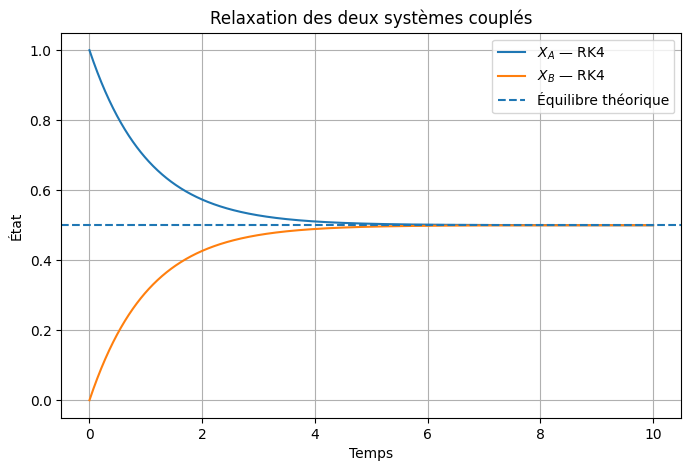

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    t_rk4,
    X_A_rk4,
    label=r"$X_A$ — RK4"
)

plt.plot(
    t_rk4,
    X_B_rk4,
    label=r"$X_B$ — RK4"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Équilibre théorique"
)

plt.xlabel("Temps")
plt.ylabel("État")
plt.title("Relaxation des deux systèmes couplés")
plt.grid(True)
plt.legend()
plt.show()

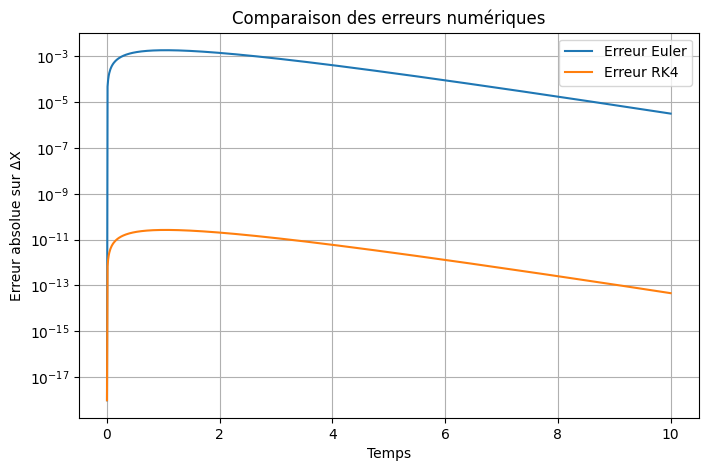

In [13]:
plt.figure(figsize=(8, 5))

plt.semilogy(
    t_euler,
    np.maximum(abs_error_euler, 1e-18),
    label="Erreur Euler"
)

plt.semilogy(
    t_rk4,
    np.maximum(abs_error_rk4, 1e-18),
    label="Erreur RK4"
)

plt.xlabel("Temps")
plt.ylabel("Erreur absolue sur ΔX")
plt.title("Comparaison des erreurs numériques")
plt.grid(True)
plt.legend()
plt.show()

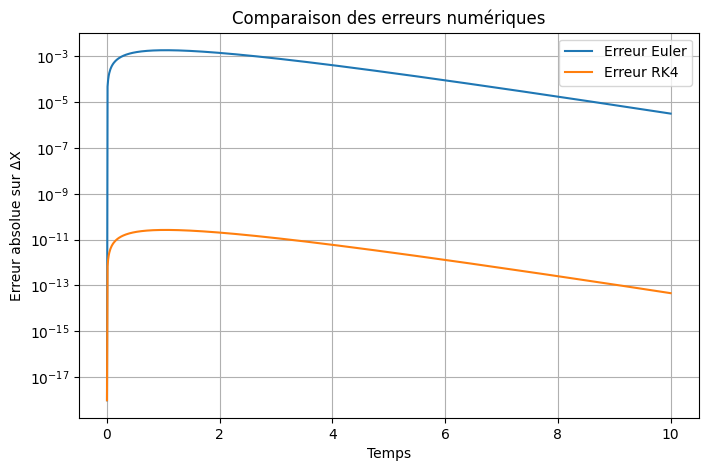

In [14]:
plt.figure(figsize=(8, 5))

plt.semilogy(
    t_euler,
    np.maximum(abs_error_euler, 1e-18),
    label="Erreur Euler"
)

plt.semilogy(
    t_rk4,
    np.maximum(abs_error_rk4, 1e-18),
    label="Erreur RK4"
)

plt.xlabel("Temps")
plt.ylabel("Erreur absolue sur ΔX")
plt.title("Comparaison des erreurs numériques")
plt.grid(True)
plt.legend()
plt.show()

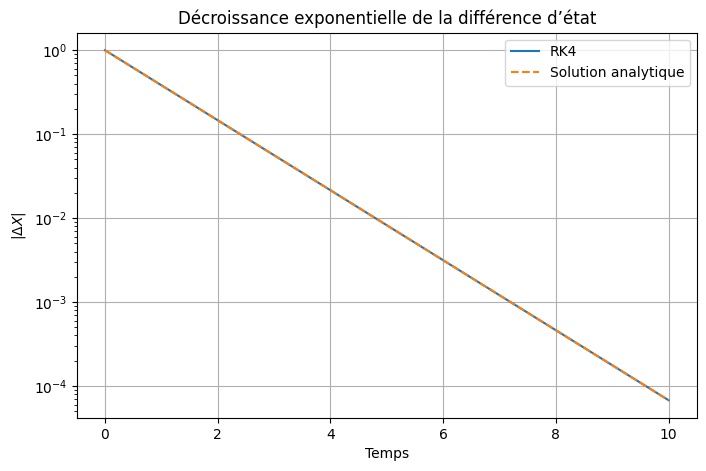

In [15]:
plt.figure(figsize=(8, 5))

plt.semilogy(
    t_rk4,
    np.maximum(np.abs(delta_rk4), 1e-18),
    label="RK4"
)

plt.semilogy(
    t_rk4,
    np.maximum(np.abs(delta_analytic_rk4_grid), 1e-18),
    linestyle="--",
    label="Solution analytique"
)

plt.xlabel("Temps")
plt.ylabel(r"$|\Delta X|$")
plt.title("Décroissance exponentielle de la différence d’état")
plt.grid(True)
plt.legend()
plt.show()

In [16]:
pd.set_option("display.precision", 15)

validation_solver = pd.Series({
    "Solveur de référence": "RK4",
    "RMSE Euler": rmse_euler,
    "RMSE RK4": rmse_rk4,
    "Gain RK4/Euler": rmse_euler / rmse_rk4,
    "Conservation RK4": np.max(
        np.abs(total_rk4 - total_rk4[0])
    ),
}, name="Validation numérique")

display(validation_solver)

,Validation numérique
Solveur de référence,RK4
RMSE Euler,0.000776387757438
RMSE RK4,0.000000000011508
Gain RK4/Euler,67465010.680167317390442
Conservation RK4,0.000000000000002


In [17]:
print(f"RMSE Euler       = {rmse_euler:.12e}")
print(f"RMSE RK4         = {rmse_rk4:.12e}")
print(f"Gain RK4/Euler   = {rmse_euler / rmse_rk4:.6e}")
print(
    "Conservation RK4 = "
    f"{np.max(np.abs(total_rk4-total_rk4[0])):.12e}"
)

RMSE Euler       = 7.763877574382e-04
RMSE RK4         = 1.150800614438e-11
Gain RK4/Euler   = 6.746501e+07
Conservation RK4 = 2.442490654175e-15


# Domaine de validité

Les simulations présentées dans ce notebook correspondent exclusivement au modèle minimal défini dans VP 0.6.

Hypothèses :

- deux variables d'état scalaires ;
- couplage symétrique ;
- système linéaire ;
- système autonome ;
- coefficient de partage constant ;
- absence de bruit ;
- absence de terme source ;
- absence de dissipation externe.

Les conclusions numériques obtenues ne sont valables que dans ce cadre.

## Conclusion intermédiaire — Validation du modèle minimal

Le modèle minimal à deux systèmes produit une relaxation exponentielle
vers un état commun tout en conservant exactement la somme des états.

La différence

\[
\Delta X = X_A-X_B
\]

suit la loi analytique

\[
\Delta X(t)
=
\Delta X_0
\exp\left(-2\kappa V_{\mathrm{sh}}t\right).
\]

La simulation RK4 reproduit cette solution avec une erreur de l’ordre de
\(10^{-11}\), tandis que la conservation est respectée à la précision
machine, de l’ordre de \(10^{-15}\).

Ces résultats valident :

1. la cohérence du couplage symétrique ;
2. le rôle physique du produit \(\kappa V_{\mathrm{sh}}\) ;
3. l’expression du temps caractéristique
   \[
   \tau_{\mathrm{VP}}
   =
   \frac{1}{2\kappa V_{\mathrm{sh}}};
   \]
4. l’utilisation de RK4 comme solveur de référence pour VP 0.7.

Cette validation concerne le modèle minimal linéaire. Elle ne démontre
pas encore que le mécanisme VP décrit une interaction physique réelle.